In [ ]:
import sys
sys.path.append('../')

import numpy as np
import cv2 as cv
import cv2
from matplotlib import pyplot as plt
import pandas
import seaborn as sns
import os
import csv
import time
from tqdm import tqdm
from myutils_vcodec_logparser import *
from myutils import *
from myutils_vcodec import *
from class_yuvfile import *

if __name__ == "__main__":
    print('Done')

In [ ]:
### TOOLS
import glob
files = glob.glob('./*')
print(files)

['./run_template.sh', './a', './plot_template.ipynb']


* joblib

In [ ]:
n_jobs = 8  # Number of parallel workers (threads/processes)
backend = "loky"  # Use "threading" for I/O-bound (file reads), "loky" for CPU-bound
compression="gzip"   # gzip vs snappy(default),  25% smaller, and 20% slower

# ----------------------
# Core Processing Function (Unchanged)
# ----------------------
def process_us_parquet(code):
    try:
        fname_out = os.path.join(path_out, f"{code}.parquet")
        if os.path.exists(fname_out):
            return (code, "skipped (file exists)")
        
        df_list = []
        valid_days = 0
        for day in range(1, 32):
            filename = rf"y:/us_zubi/{year:04d}{month:02d}{day:02d}/{code}.parquet"
            if not os.path.exists(filename):
                continue
            df = pd.read_parquet(filename, engine="pyarrow")
            df_list.append(df)
            valid_days += 1
        
        if df_list:
            df_all = pd.concat(df_list, ignore_index=False)
            df_all.to_parquet(fname_out, engine="pyarrow", compression=compression, index=True)
            return (code, f"success (valid days: {valid_days})")
        else:
            return (code, "failed (no valid data)")
    
    except Exception as e:
        return (code, f"failed (error: {str(e)[:80]})")            

# Parallel execution with Joblib + tqdm progress bar
print(f"Starting processing with {n_jobs} workers (backend: {backend})...")
results = Parallel(
    n_jobs=n_jobs,          # Number of parallel workers
    backend=backend,        # Threading (I/O) or multiprocessing (CPU)
    verbose=0,              # Disable Joblib's default verbose (use tqdm instead)
    pre_dispatch="2*n_jobs" # Pre-dispatch tasks to avoid overload
)(
    delayed(process_us_parquet)(code) for code in tqdm(
        codes[:],
        desc='us',
        colour='green',
        mininterval=10,
        unit="code"
    )
)

# Print summary report
print("\n=== Processing Summary ===")
success = 0
skipped = 0
failed = 0
for code, status in results:
    # print(f"{code:<10} | {status}")
    if "success" in status:
        success += 1
    elif "skipped" in status:
        skipped += 1
    else:
        failed += 1

print(f"\nTotal: {len(codes)} | Success: {success} | Skipped: {skipped} | Failed: {failed}")

In [ ]:
from joblib import Parallel, delayed

def run_one_cmd(cmds):
    logf, dirname = cmds
    p = CHECKLOG_VCE_H264()
    p.parse_vce_log2data(logf, dirname)
    del p
    return (key, ctb_sad, ctb_me_mvx, ctb_me_mvy, None)            

if len(joblib_cmds) > 0 and True:
    # print('joblib_cmds', len(joblib_cmds))
    tr_txt = []
    n_jobs = 4
    tr_txt += Parallel(n_jobs=n_jobs, verbose=2)(delayed(run_one_cmd)(cmds) for log_idx, cmds in enumerate(joblib_cmds[:]))

* Numpy

In [ ]:
had4_4.flatten().tolist()

* Read encoded stream

In [ ]:
fname_bin0 = './202502/MI14_QPdelta_ducks_take_off_1080p50_30fps_0B3000000_br2339000.h264'
fname_bin1 = './202502/duck_3000000_rdo1_ctbRc1_gop1_maxB7.h264'

ffmpeg_decoded_to_yuv420p(fname_bin0, fname_bin0.replace('.h264', '.yuv'))
ffmpeg_decoded_to_yuv420p(fname_bin1, fname_bin1.replace('.h264', '.yuv'))
# print(stdout)

types0, mbtypes0 = ffmpeg_get_mbtype(fname_bin0, frames=180)
types1, mbtypes1 = ffmpeg_get_mbtype(fname_bin1, frames=180)

_, qpss0 = ffmpeg_get_qp(fname_bin0, frames=180)
_, qpss1 = ffmpeg_get_qp(fname_bin1, frames=180)

* Read/Write YUV

In [ ]:
picw = 1920
pich = 1080

# yuvfile = '/mnt/nas2_tommy/codecPK/yuv420p/ducks_take_off_1080p50.yuv'
yuvfile = '/mnt/nas2_tommy/codecPK/yuv420p/crowd_run_1080p50.yuv'

fname_out = 'out/crowdrun_rskip_%dx%d.yuv' % (picw, pich)
fpw = open(fname_out, 'wb')

p0 = YUVFILE()  # input
p0.loadfile(yuvfile, picw, pich)

for frameidx in tqdm(range(10)):
    _, dataY0, dataU0, dataV0 = p0.read_YUV(frameidx, 0, 0, picw, pich)
    dataU = np.zeros((pich//2, picw//2), np.uint8)
    dataV = np.zeros((pich//2, picw//2), np.uint8)
    dataU.fill(128)
    dataV.fill(128)

    fpw.write(dataY0)
    fpw.write(dataU)
    fpw.write(dataV)

fpw.close()
print('Saved.', fname_out)

In [ ]:
import cv2
yuv0 = "/mnt/nas_roger/sequences/yuv_stream/customer/xiaomi/Spreadsheet_1920x1080_30fps_8bit_420.yuv"
picw, pich = 1920, 1080  # res.split('x')
yuv1 = 'in/logff_spreadsheet_gt_h265.mp4.yuv'
yuv2 = 'in/logff_testenc_opt_psy075_chromae2_ctbv2_Spreadsheet_2156000_rdo3_ctbRc3_gop0_maxB7.hevc.yuv'
yuv3 = 'in/logff_testenc_opt_psy075_chromae2_ctbv2_Spreadsheet_2156000_rdo3_ctbRc3_gop1_maxB7.hevc.yuv'

p0 = YUVFILE()  # input
p0.loadfile(yuv0, w=picw, h=pich)

p1 = YUVFILE()  # input
p1.loadfile(yuv1, w=picw, h=pich)
p2 = YUVFILE()  # input
p2.loadfile(yuv2, w=picw, h=pich)
p3 = YUVFILE()  # input
p3.loadfile(yuv3, w=picw, h=pich)

frames = int(p1.framecnt)
for fidx in tqdm(range(frames//10)):
    _, dataY0, dataU0, dataV0 = p0.read_YUV(fidx, 0, 0, picw, pich)
    _, dataY1, dataU1, dataV1 = p1.read_YUV(fidx, 0, 0, picw, pich)
    _, dataY2, dataU2, dataV2 = p2.read_YUV(fidx, 0, 0, picw, pich)
    _, dataY3, dataU3, dataV3 = p3.read_YUV(fidx, 0, 0, picw, pich)

    dataY_write = dataY0.copy()
    bs = 16
    for y in range(0, pich-bs, bs):
        for x in range(0, picw-bs, bs):
            blk = dataY_write[y:y+bs, x:x+bs].copy()
            if mad < (0.1*mean):
                p0.draw_rect(dataY_write, picw, pich, x, y, bs,
                             bs, rectvalue=255, linewidth=1)

# draw text on YUV
# https://blog.csdn.net/qq_41273999/article/details/134597738
cv2.putText(dataY0, 'Frame199', (300, 300),
            cv2.FONT_HERSHEY_SIMPLEX, .5, (228, 228, 228), 2, cv2.LINE_AA)

In [ ]:
# write YUV file
filter_out = './Spreadsheet_1920x1080_ssim_DEV.yuv'
fpw = open(filter_out, "wb")
fpw.write(filterY)
fpw.write(dataU2)
fpw.write(dataV2)
fpw.close()
print('Saved', filter_out)

* Pandas

In [ ]:
df = pandas.read_csv('./test.csv', sep='\t')
print(df.info())
print(df[['a'],['b']])
print(df[[0]])
print(df[list(range(5))])

mySeries.to_frame()     # to DateFrame

# select
df = df[(df.satd8 >= 3900) & (df.satd8 <= 4000)]
df_select = df[(df['psnr_diff'].abs() > 5) & (df['ssim_diff'].abs() > 0.05)]

# Random select 0.1%, and reset_index
df = df.sample(frac=0.001).reset_index(drop=True)

# 随机选择 100 行
df_sample = df.sample(n=100, random_state=42)


# new column
df['cat'] = np.where(df['satd8'] > df['satd4sum'], 0, 1)

# concat
pd.concat([df0, df1])
df0.append(df1)

# melt, 比如把多个column, 分解成两个column
## 
df = pd.melt(df, id_vars='religion')

# fillna
df.fillna(method='ffill')

# export
df.to_parquet('./temp.pq')
import pyarrow.parquet as pq
df = pq.ParquetFile('./temp.pq').read().to_pandas()

# iter
for _, row in tick_data.iterrows():
    # 如果当前没有正在处理的订单，开始一个新的
    if current_order is None:
        current_order = row.to_dict()
        continue
    
# melt
# 方法1: 使用melt函数重塑（推荐）
reshaped_df = df.melt(
    id_vars=['frame'],  # 保留的列
    value_vars=['A', 'B'],  # 需要合并的列
    value_name='breath_diff',  # 合并后的列名
    var_name='file',        # use as hue of seaborn
)#.drop(columns=['variable'])  # 移除多余的变量列    

* Pandas plot

In [ ]:
df[['a'],['b']].plot.hist()
df.plot.hist(x='a', y='b')

* Pandas / Seaborn

              cat       frame        psnr        ssim
count  100.000000  100.000000  100.000000  100.000000
mean     4.610000    5.060000    4.960000    4.970000
std      2.740991    2.505832    2.612789    2.649395
min      1.000000    1.000000    1.000000    1.000000
25%      2.000000    3.000000    3.000000    3.000000
50%      4.000000    5.000000    5.000000    5.000000
75%      7.000000    7.000000    7.000000    7.000000
max      9.000000    9.000000    9.000000    9.000000


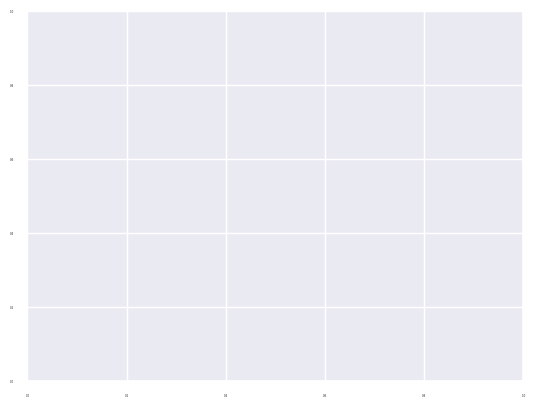

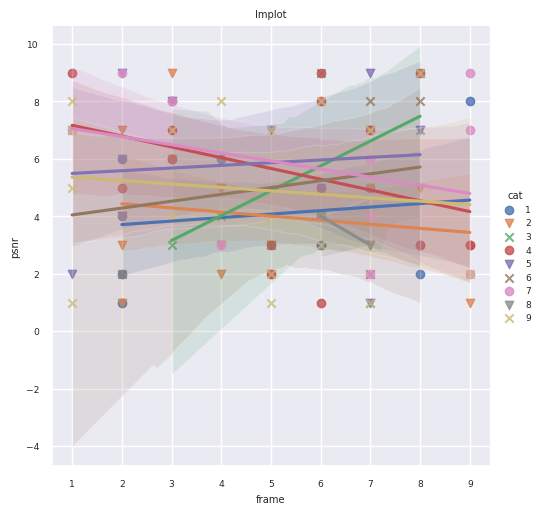

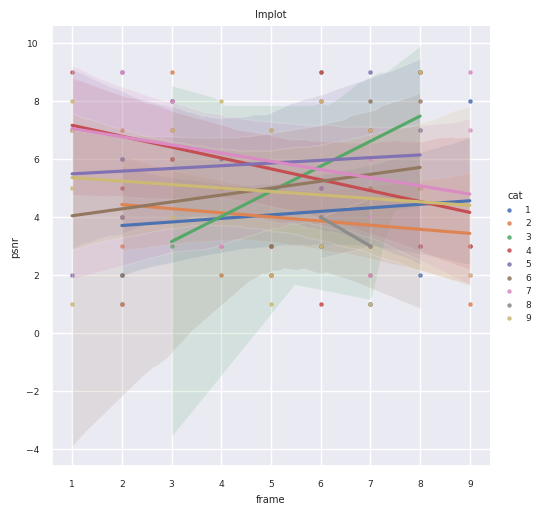

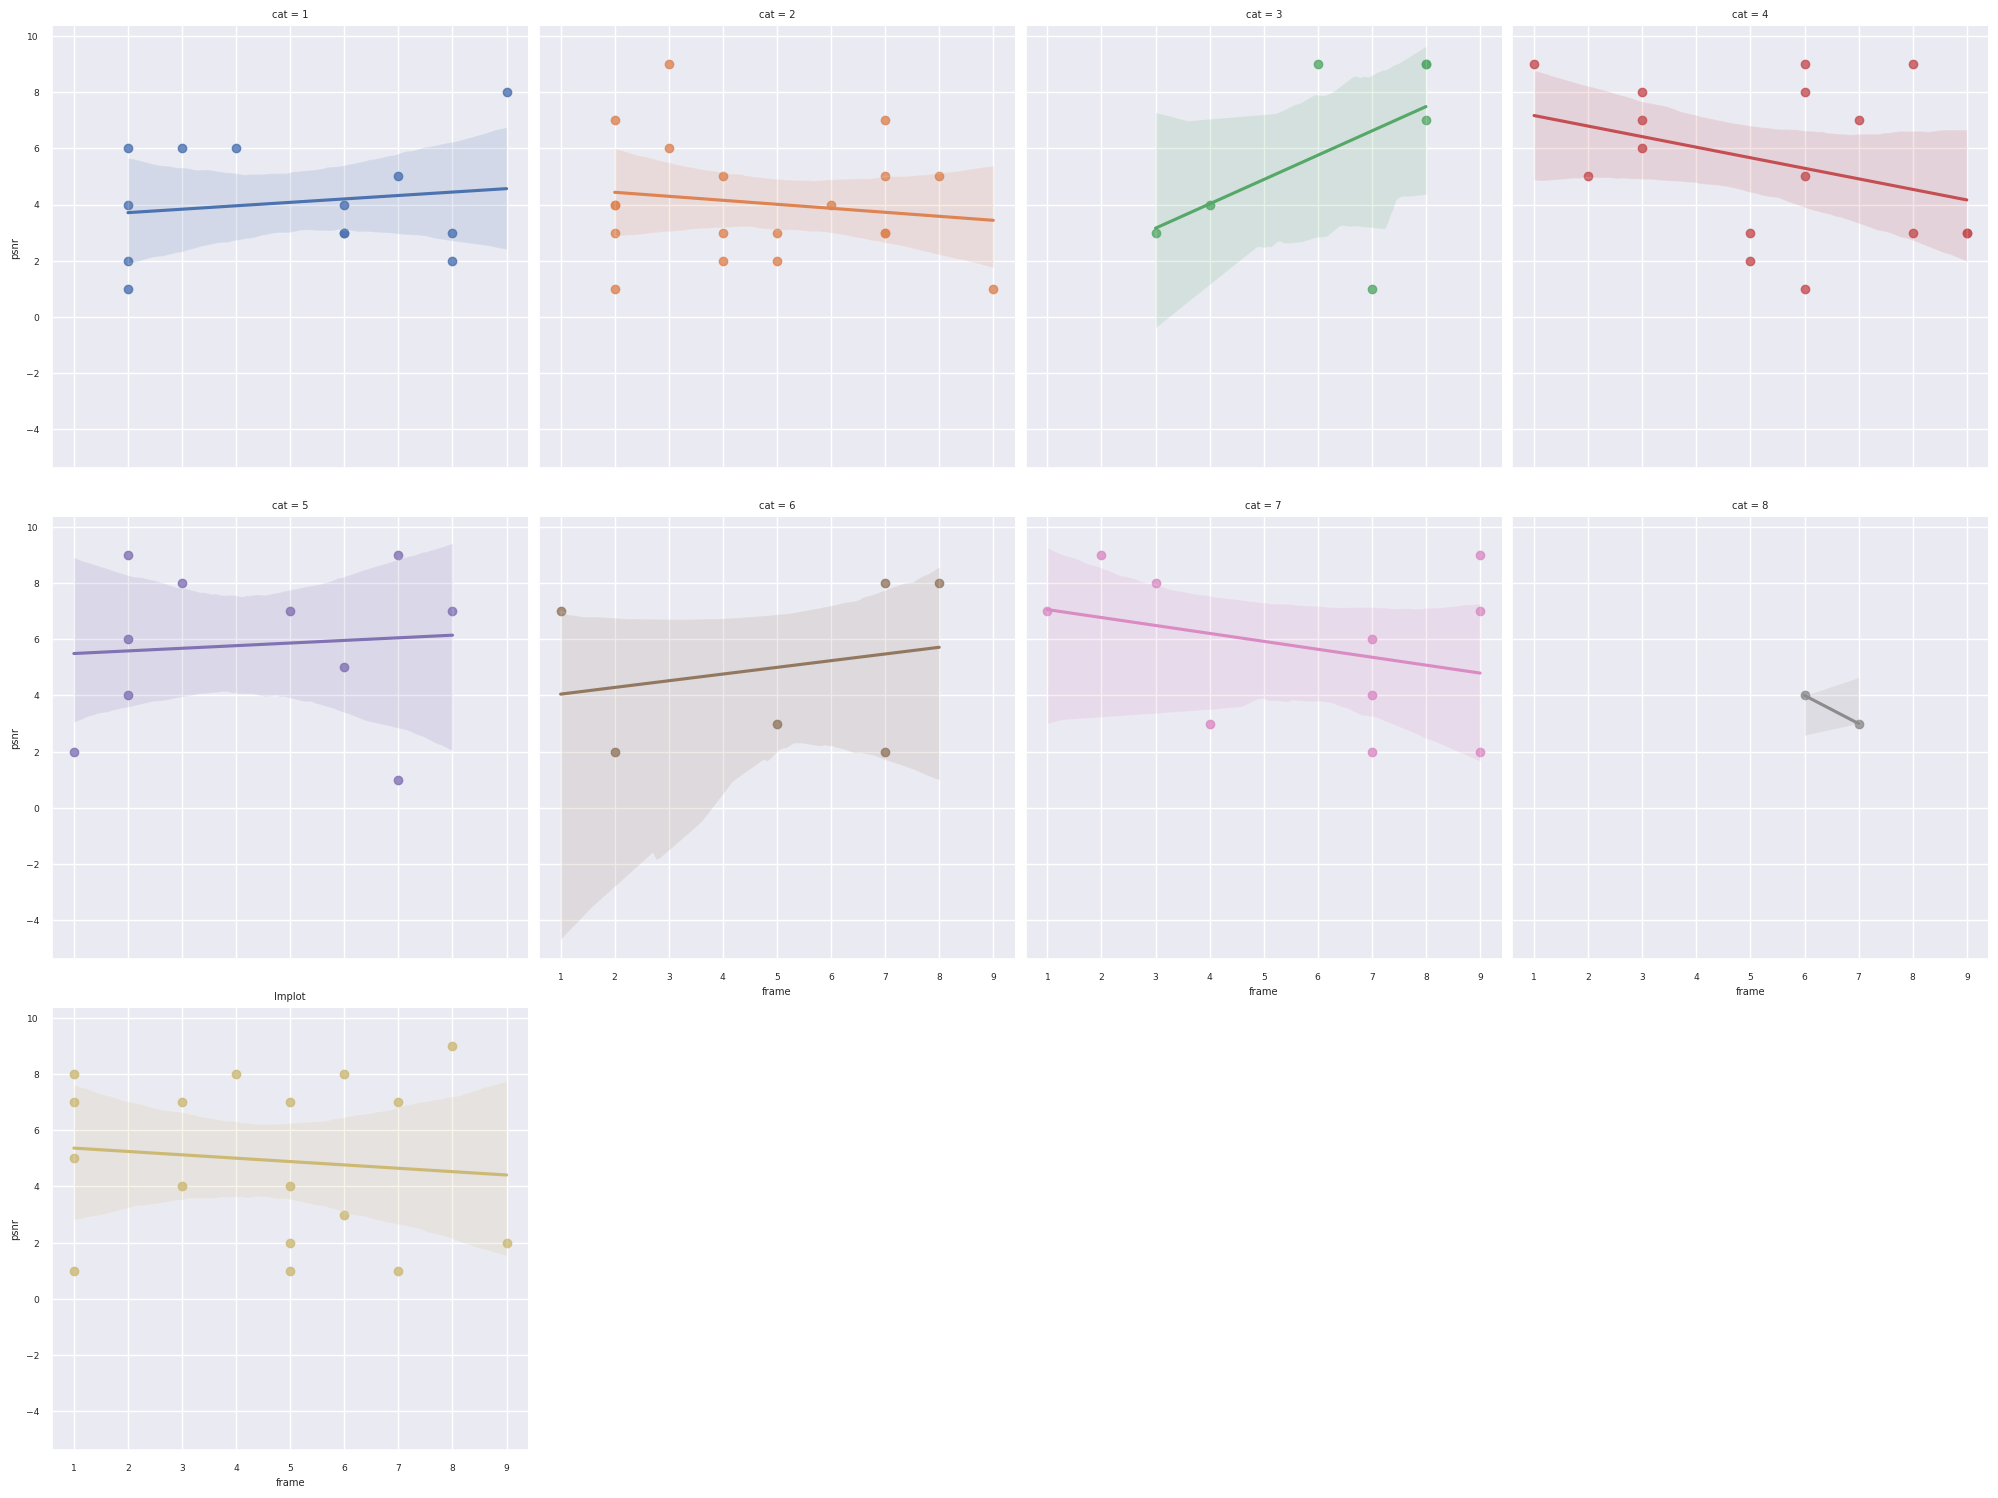

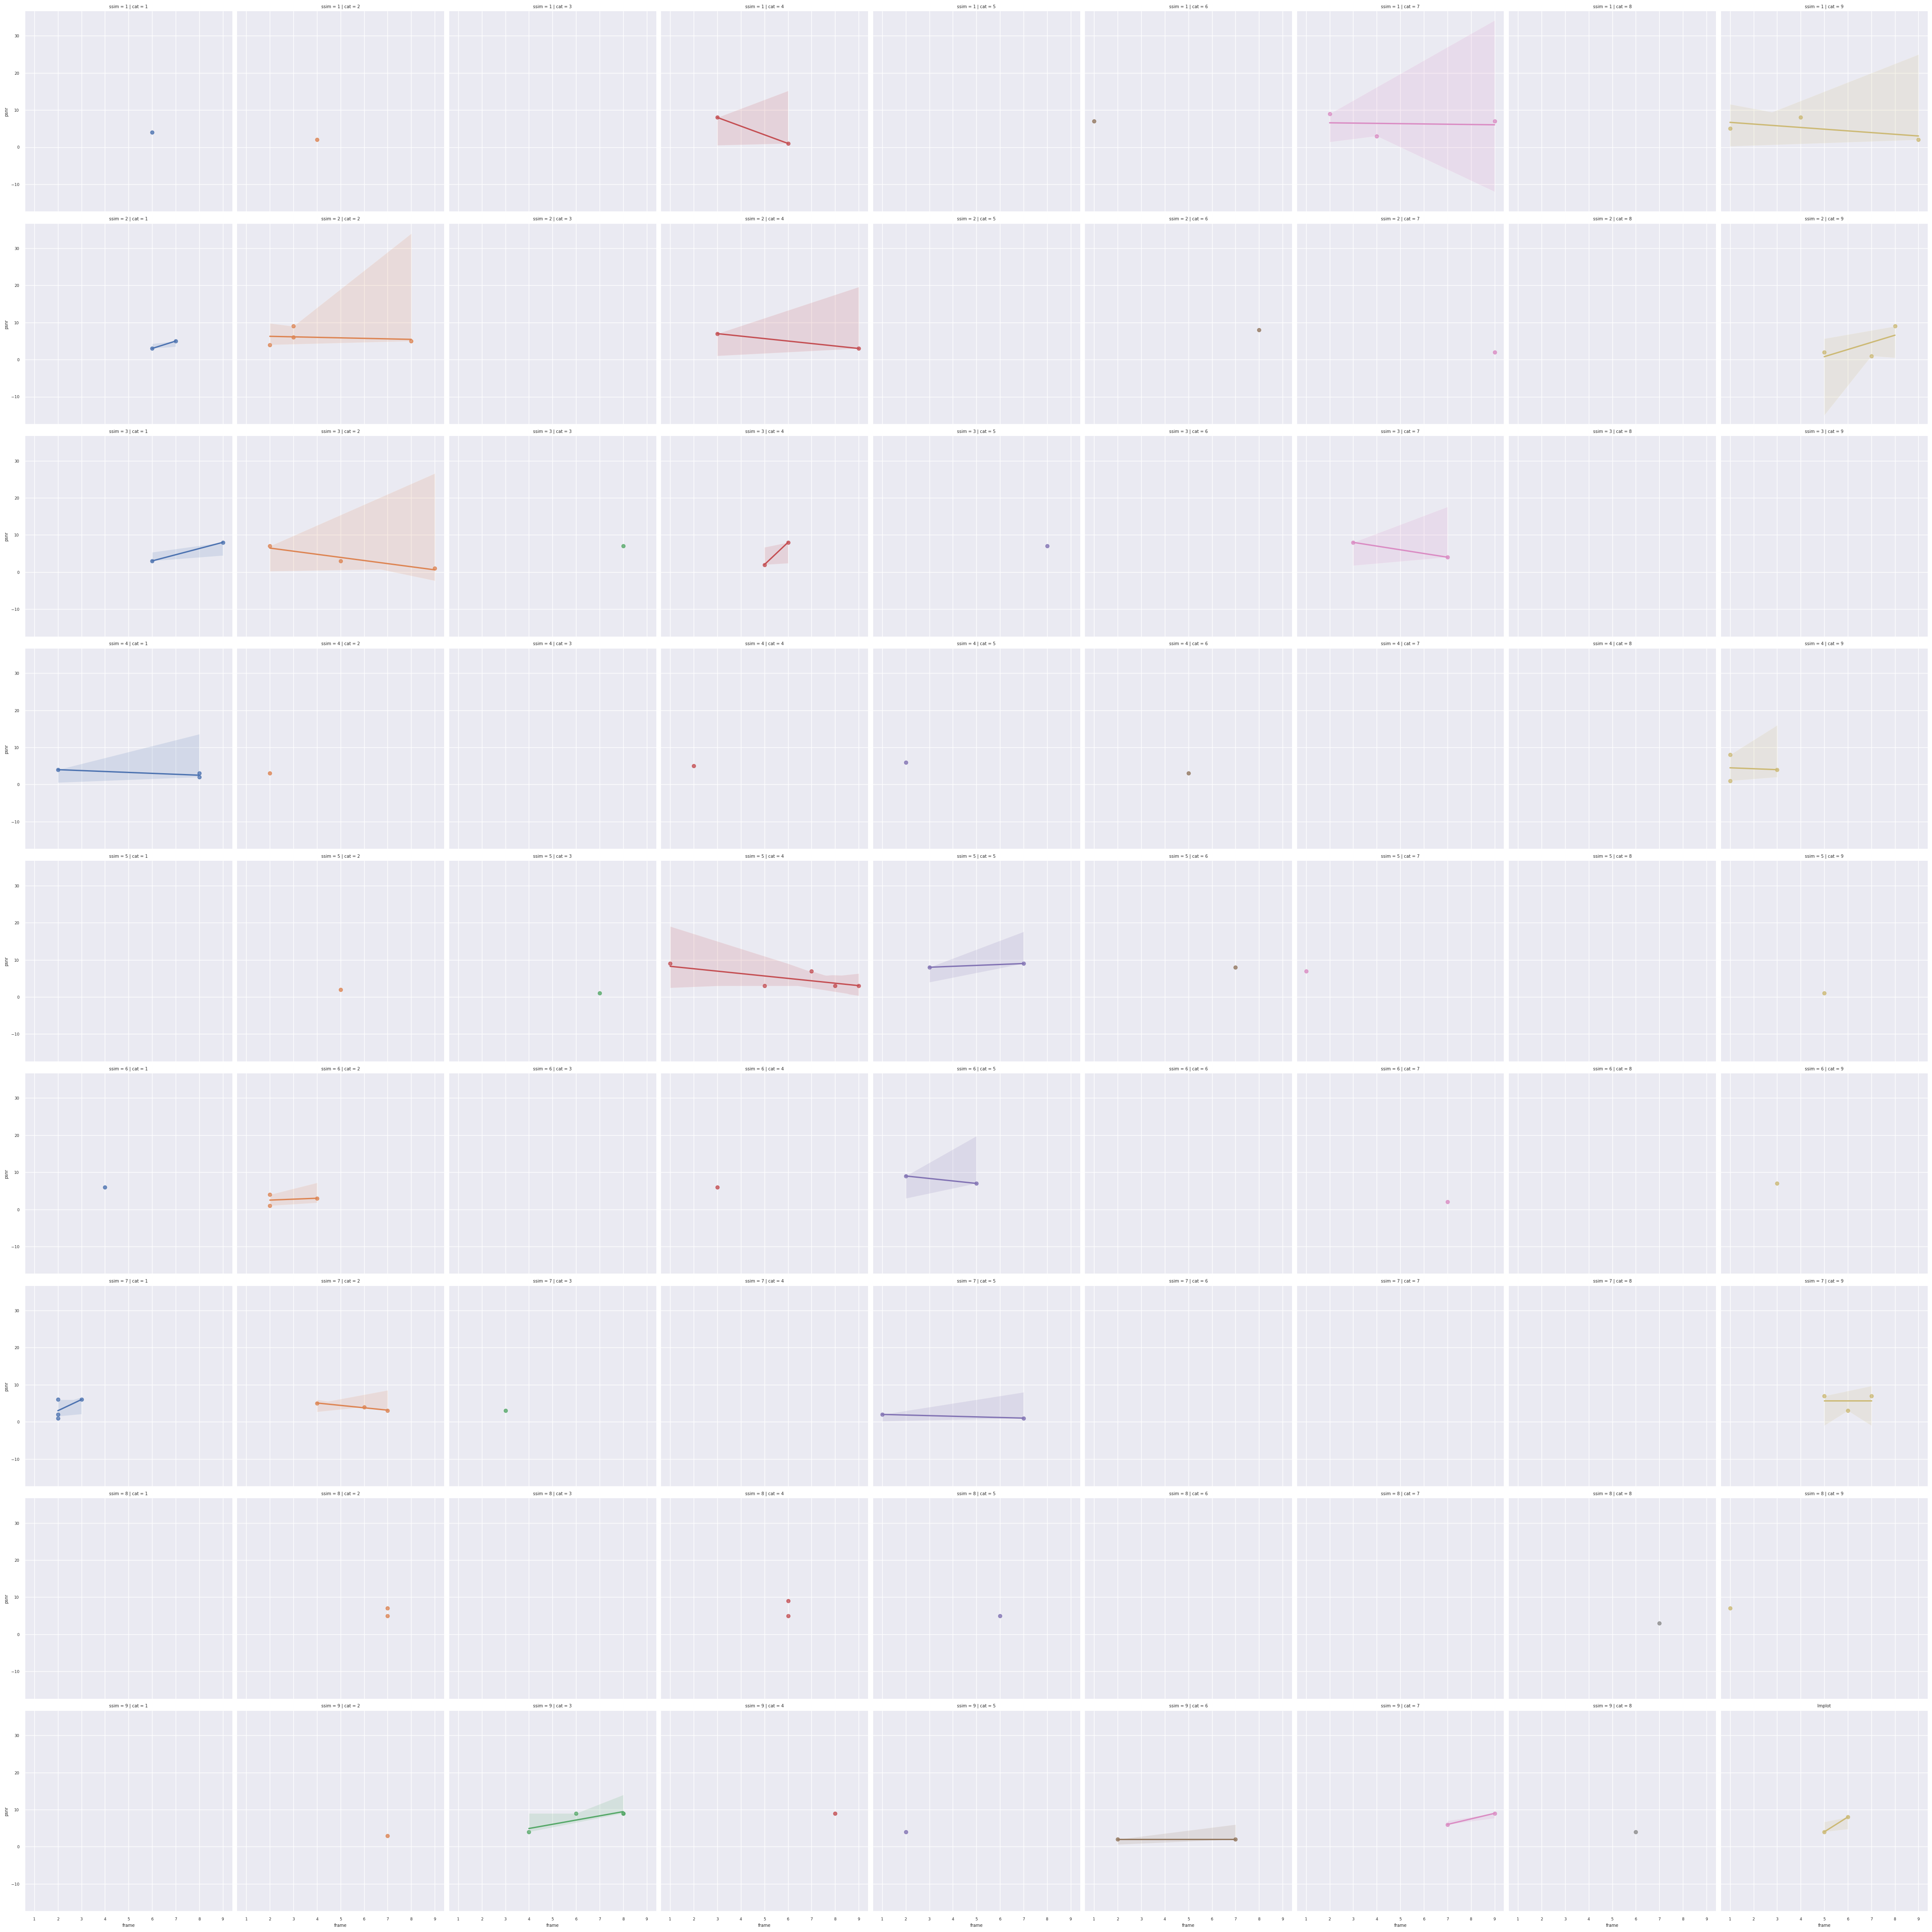

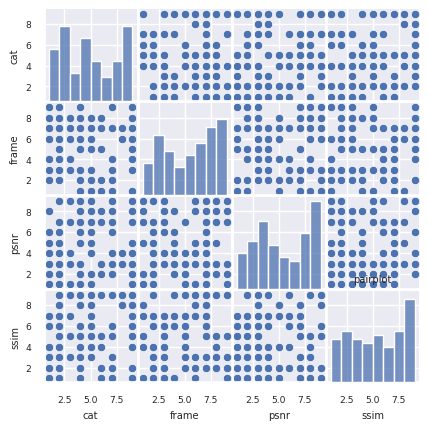

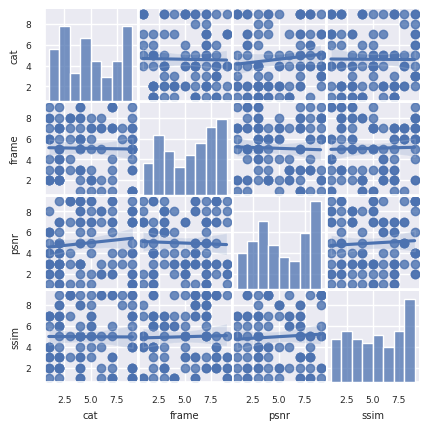

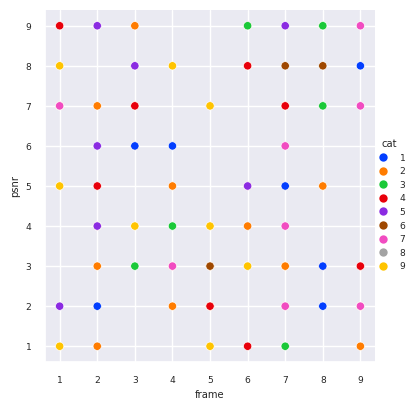

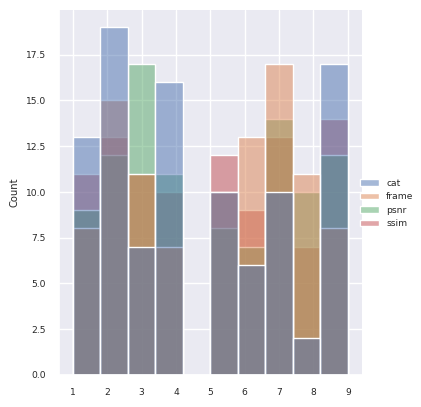

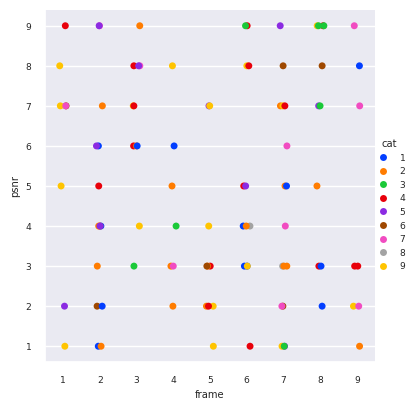

kind scatter


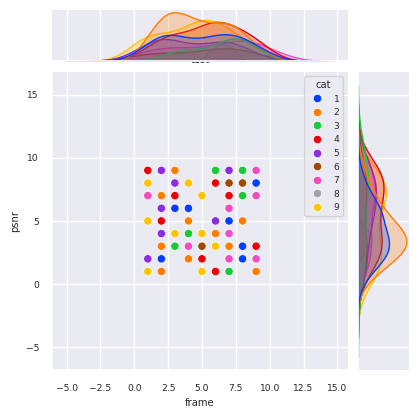

kind hist


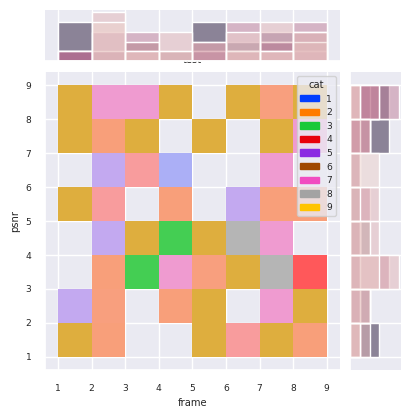

kind kde


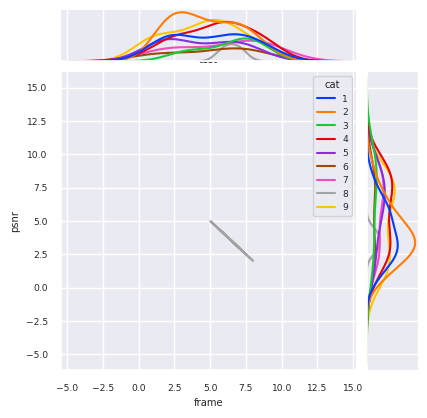

jointplot kind hex


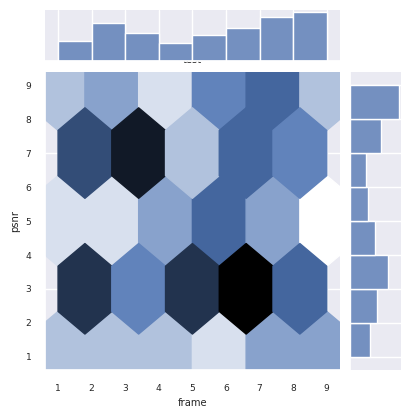

jointplot kind reg


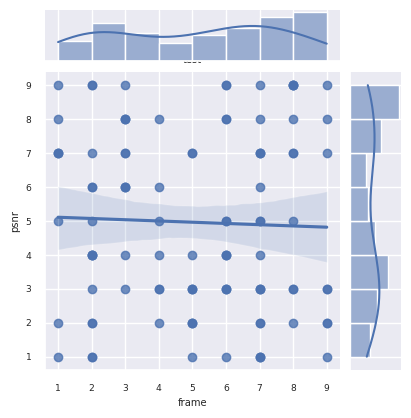

jointplot kind resid


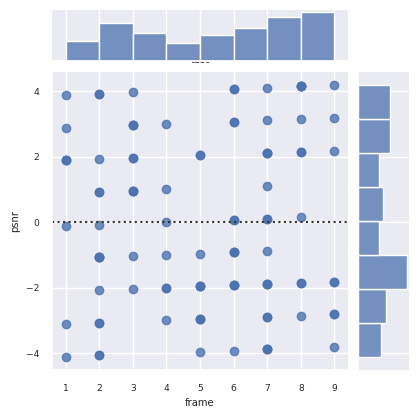

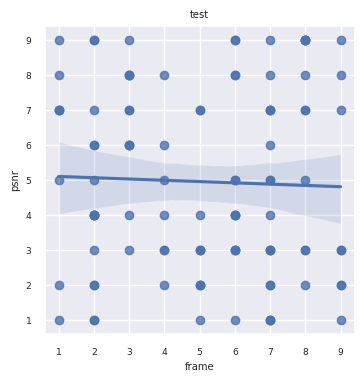

In [ ]:
stat = np.random.randint(low=1, high=10, size=(100, 4))
df = pandas.DataFrame(stat, columns=('cat', 'frame', 'psnr', 'ssim'))
print(df.describe())

# plt.figure(figsize=(20, 9),)# facecolor='white', edgecolor='grey')
sns.set_style("whitegrid")
sns.color_palette("dark")
sns.set(font_scale=.6)
# plt.rcParams['font.sans-serif'] = ['SimHei'] # 使用中文字体

plt.xticks(fontsize=2)
plt.yticks(fontsize=2)
# ax.set_xticks([0, 200000, 400000])  # 设置x轴刻度
# ax.set_xlabel("LabelName", fontsize=20)
# ax.set_ylabel("LabelName", fontsize=20)
# plt.xticks(fontsize=20, rotation=30)
# plt.yticks(fontsize=20, rotation=30)

# joinplot, plot_kinds = ["scatter", "hist", "hex", "kde", "reg", "resid"]
# ax = sns.jointplot(x='frame', y='psnr', data=df, hue='cat', palette='bright')
# ax.figure.set_size_inches(4, 4)     # this work !
# plt.title('test')
# plt.show()

sns.lmplot(x='frame', y='psnr', data=df, hue='cat', markers=['o','v','x']*3) # scatter_kws={'s' : df['ssim']})
plt.title('lmplot')
plt.show()

sns.lmplot(x='frame', y='psnr', data=df, hue='cat', scatter_kws={'s':5})
plt.title('lmplot')
plt.show()

sns.lmplot(x='frame', y='psnr', data=df, hue='cat', col='cat', col_wrap=4)
plt.title('lmplot')
plt.show()

# sns.lmplot(x='frame', y='psnr', data=df, hue='cat', col='cat', row='ssim')
# plt.title('lmplot')
# plt.show()


ax = sns.pairplot(df)
ax.figure.set_size_inches(4, 4)
plt.title('pairplot')
plt.show()

ax = sns.pairplot(df, kind='reg')
ax.figure.set_size_inches(4, 4)
plt.show()

ax = sns.relplot(x='frame', y='psnr', data=df, hue='cat', palette='bright')
ax.figure.set_size_inches(4, 4)
plt.show()

ax = sns.displot(df)
ax.figure.set_size_inches(4, 4)
plt.show()

ax = sns.catplot(x='frame', y='psnr', data=df, hue='cat', palette='bright')
ax.figure.set_size_inches(4, 4)
plt.show()

for kind in ["scatter", "hist", "kde", ]:
    print('kind', kind)
    ax = sns.jointplot(x='frame', y='psnr', data=df,
                       hue='cat', palette='bright', kind=kind)
    ax.figure.set_size_inches(4, 4)     # this work !
    plt.title('test')
    plt.show()

for kind in ["hex", "reg", "resid"]:
    print('jointplot kind', kind)
    ax = sns.jointplot(x='frame', y='psnr', data=df,
                       palette='bright', kind=kind)
    ax.figure.set_size_inches(4, 4)     # this work !
    plt.title('test')
    plt.show()


# ax = sns.pairplot(x='frame', y='psnr', data=df, hue='cat', palette='bright')
# plt.title('test')
# plt.show()

ax = sns.regplot(x='frame', y='psnr', data=df)
ax.figure.set_size_inches(4, 4)     # this work !
plt.title('test')
plt.show()


# ax = sns.jointplot(x='frame', y='ssim', data=df, hue='cat', palette='bright')
# ax.figure.set_size_inches(12, 6)
# plt.show()

# plt.title('pearson corr %f' %(df['psy_intra'].corr(df[key],method="pearson")))

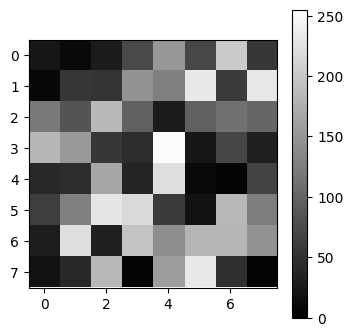

In [ ]:
# plt.clf()         # 显示灰度图 !
# plt.cla()
minval = 0
maxval = 255
# fig, ax = plt.subplots()
plt.figure(figsize=(4, 4),)
# ax.set_xticks(np.arange(0, 48, 16))
# ax.set_yticks(np.arange(0, 48, 16))
plotdata = np.random.randint(low=0, high=255, size=(8, 8))
plt.imshow(plotdata, cmap='gray', vmin=minval, vmax=maxval)
plt.grid(False)
plt.colorbar()
# plt.savefig(fnameout)
# plt.close()
plt.show()

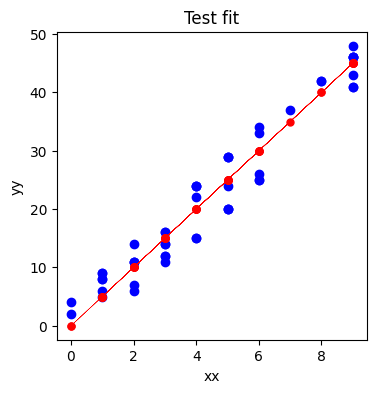

In [ ]:
X = np.random.randint(low=0, high=10, size=(50))
y = 5 * X + np.random.randint(low=-5, high=5, size=(50))
y_pred = 5 * X
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111)
ax.scatter(X, y, c='b')
ax.plot(X, y_pred, 'ro-', linewidth=.2, markersize=5)
plt.title('Test fit')
plt.xlabel('xx')
plt.ylabel('yy')
plt.show()

   TV  radio  sales
0   6      3     56
1   8      0     39
2   5      7    106
3   2      7     85
4   1      0     12
   TV  radio  sales  sales_pred
0   6      3     56   58.718382
1   8      0     39   32.716763
2   5      7    106   95.118766
3   2      7     85   76.980702
4   1      0     12   12.300617
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     240.3
Date:                Fri, 14 Mar 2025   Prob (F-statistic):           4.17e-28
Time:                        17:43:30   Log-Likelihood:                -173.03
No. Observations:                  50   AIC:                             354.1
Df Residuals:                      46   BIC:                             361.7
Df Model:                           3                   

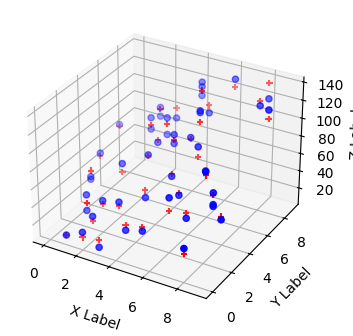

In [ ]:
import numpy as np
import pandas as pd
# import statsmodels.api as sm #方法一
import statsmodels.formula.api as smf  # 方法二
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# df = pd.read_csv('http://www-bcf.usc.edu/~gareth/ISL/Advertising.csv', index_col=0)
X1 = np.random.randint(low=0, high=10, size=(50))
X2 = np.random.randint(low=0, high=10, size=(50))
y = 5 * X1 + 10*X2 + np.random.randint(low=-15, high=15, size=(50))

data = np.stack((X1, X2, y), axis=1)
# print_ndarray(data)
df = pandas.DataFrame(data, columns=['TV', 'radio', 'sales'])
print(df.head())

X = df[['TV', 'radio']]
y = df['sales']

def myfunc(radio):
    return np.pow(radio, 3)

# #est = sm.OLS(y, sm.add_constant(X)).fit() #方法一
# https://www.statsmodels.org/stable/example_formulas.html
est = smf.ols(formula='sales ~ TV + radio + (TV-radio)*np.log(radio) + myfunc(radio)',
              data=df).fit()  # 方法二
y_pred = est.predict(X)

df['sales_pred'] = y_pred
print(df.head())
print(est.summary())  # 回归结果
print(est.params)  # 系数

# fig = plt.figure()
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')  # ax = Axes3D(fig)
ax.scatter(X['TV'], X['radio'], y, c='b', marker='o')
ax.scatter(X['TV'], X['radio'], y_pred, c='r', marker='+')
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
print(df.head())
print('STD', np.sum(np.mean(np.square(df['sales'] - df['sales_pred']))))
plt.show()

dddddd